### Red predictora partidos

En este trabajo se buscará optimizar las ganancias en un ciclo de apuestas realizadas por dos modelos predictores principales, uno que buscará predecir el ganador de los partidos de futbol en las 5 grandes ligas europeas durante las últimas 5 temporadas desde la 2021/2022 hasta la reciente 2025/2026 y otro que decidirá si en el partido hay más o menos de 2.5 goles, la base de datos a utilizar es footbal_data.co.uk.

Para ambos modelos se tomarán en cuenta estadísticas recientes de los equipos incluyendo rachas de tiros y de tiros a puerta, rachas de puntos, rachas de goles, rachas de puntos y una nueva estadística agregada $ELO$ que refleja un puntuaje a cada equipo según sus partidos a lo largo de los 5 años, el puntuaje ELO incrementa o disminuye considerando el resultado del partido y el puntuaje ELO del rival al momento del enfrentamiento.

In [1]:
import soccerdata as sd
import pandas as pd
import requests
import io
import numpy as np

#SP1: LaLiga, I1: Serie A, D1: Bundesliga, F1: Ligue 1
ligas = ['E0', 'SP1', 'I1', 'D1', 'F1']
temporadas = ['2122', '2223','2324', '2425', '2526'] 
base_url = "https://www.football-data.co.uk/mmz4281/{}/{}.csv"

dfs = []

for liga in ligas:
    for temp in temporadas:
        try:
            url = base_url.format(temp, liga)
            s = requests.get(url).content
            df_temp = pd.read_csv(io.StringIO(s.decode('latin-1')))
            df_temp['League_ID'] = liga # Para guardar cada liga
            dfs.append(df_temp)
        except:
            continue

df_main = pd.concat(dfs, ignore_index=True)


cols_home = [c for c in df_main.columns if c.endswith('H') and c not in ['FTHG', 'HTHG']] 
cols_draw = [c for c in df_main.columns if c.endswith('D')]
cols_away = [c for c in df_main.columns if c.endswith('A') and c not in ['FTAG', 'HTAG']]

for col in cols_home + cols_draw + cols_away:
    df_main[col] = pd.to_numeric(df_main[col], errors='coerce')

# Promedio de cuotas de apuestas (hay varias casas de apuestas)
df_main['Odds_Home'] = df_main[cols_home].mean(axis=1)
df_main['Odds_Draw'] = df_main[cols_draw].mean(axis=1)
df_main['Odds_Away'] = df_main[cols_away].mean(axis=1)

df_clean = df_main.dropna(subset=['Odds_Home', 'Odds_Away', 'FTHG']).copy()
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True)

# Calculamos puntos hechos en los partidos
condiciones = [
    (df_clean['FTHG'] > df_clean['FTAG']), # Gana Local
    (df_clean['FTHG'] == df_clean['FTAG']), # Empate
    (df_clean['FTHG'] < df_clean['FTAG'])  # Gana Visita
]
# Puntos para el Local
df_clean['Home_Pts'] = np.select(condiciones, [3, 1, 0]) # victoria = 3puntos, empate =1 punto, derrota = 0 puntos
# Puntos para el Visitante
df_clean['Away_Pts'] = np.select(condiciones, [0, 1, 3])

# Seleccionamos columnas importantes (tiros, goles, tiros al arco, casas de apuestas, puntos)
cols_keep = ['Date', 'League_ID', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 
             'Odds_Home', 'Odds_Draw', 'Odds_Away', 'Home_Pts', 'Away_Pts']
df_modelo = df_clean[cols_keep].sort_values('Date')


# Obtenemos las rachas de tiros, goles y puntos para cada equipo
def calcular_rachas_complejas(df):
    # Partidos de local
    home = df[['Date', 'HomeTeam', 'HS', 'AS', 'HST', 'AST', 'FTHG', 'FTAG', 'Home_Pts']].rename(
        columns={
            'HomeTeam': 'Team',
            'HS': 'Shots_Total_For',   'AS': 'Shots_Total_Ag',   # Tiros Totales (A favor / En contra)
            'HST': 'Shots_Target_For', 'AST': 'Shots_Target_Ag', # Tiros Arco (A favor / En contra)
            'FTHG': 'Goals_For',       'FTAG': 'Goals_Ag',
            'Home_Pts': 'Pts'
        }
    )
    
    # Partidos de visita 
    away = df[['Date', 'AwayTeam', 'AS', 'HS', 'AST', 'HST', 'FTAG', 'FTHG', 'Away_Pts']].rename(
        columns={
            'AwayTeam': 'Team',
            'AS': 'Shots_Total_For',   'HS': 'Shots_Total_Ag',   # Al revés para el visitante
            'AST': 'Shots_Target_For', 'HST': 'Shots_Target_Ag',
            'FTAG': 'Goals_For',       'FTHG': 'Goals_Ag',
            'Away_Pts': 'Pts'
        }
    )
    
    combined = pd.concat([home, away]).sort_values(['Team', 'Date'])
    
    # Obtenemos el promedio de los últimos 5 partidos para las siguientes métricas.
    metricas = ['Shots_Total_For', 'Shots_Total_Ag', 
                'Shots_Target_For', 'Shots_Target_Ag', 
                'Goals_For', 'Goals_Ag', 'Pts']
    
    for metrica in metricas:
        # Creamos la columna "Form_..."
        combined[f'Form_{metrica}'] = combined.groupby('Team')[metrica].transform(
            lambda x: x.shift().rolling(window=5, min_periods=3).mean()
        )
    
    return combined

df_rachas = calcular_rachas_complejas(df_modelo)

# Definimos las columnas que recién creamos
cols_a_usar = ['Date', 'Team', 
               'Form_Shots_Total_For', 'Form_Shots_Total_Ag',
               'Form_Shots_Target_For', 'Form_Shots_Target_Ag',
               'Form_Goals_For', 'Form_Goals_Ag', 
               'Form_Pts']

# Pegar al Local
df_final = pd.merge(df_modelo, df_rachas[cols_a_usar], 
                    left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='inner')

# Renombrar Local (Añadiendo Home_)
mapa_renombre_local = {col: f"Home_{col.replace('Form_', '')}_Form" for col in cols_a_usar if col not in ['Date', 'Team']}
df_final.rename(columns=mapa_renombre_local, inplace=True)
df_final.drop(columns=['Team'], inplace=True)

# Pegar al Visitante 
df_final = pd.merge(df_final, df_rachas[cols_a_usar], 
                    left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='inner')

# Renombrar Visitante (Añadiendo Away_)
mapa_renombre_visita = {col: f"Away_{col.replace('Form_', '')}_Form" for col in cols_a_usar if col not in ['Date', 'Team']}
df_final.rename(columns=mapa_renombre_visita, inplace=True)
df_final.drop(columns=['Team'], inplace=True)

df_final.dropna(inplace=True)

print(f"Tenemos: {df_final.shape[0]} partidos procesados.")

print(df_final.head())

[03/17/26 21:02:33] INFO     No custom team name replacements found. You can configure these in       ]8;id=560516;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=695553;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\soccerdata\_config.py#92\92]8;;\
                             C:\Users\Moises\soccerdata\config\teamname_replacements.json.                         

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=575320;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=583312;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\soccerdata\_config.py#198\198]8;;\
                             C:\Users\Moises\soccerdata\config\league_dict.json.                                   

[03/17/26 21:03:42] WARNING  C:\Users\Moises\AppData\Local\Temp\ipykernel_10628\4244179876.py:36:   ]8;id=594865;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=573596;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               df_main['Odds_Home'] = df_main.mean(axis=1)                                         
                                                                                                                   

                    WARNING  C:\Users\Moises\AppData\Local\Temp\ipykernel_10628\4244179876.py:37:   ]8;id=122838;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=195418;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               df_main['Odds_Draw'] = df_main.mean(axis=1)                                         
                                                                                                                   

                    WARNING  C:\Users\Moises\AppData\Local\Temp\ipykernel_10628\4244179876.py:38:   ]8;id=659589;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=759603;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               df_main['Odds_Away'] = df_main.mean(axis=1)                                         
                                                                                                                   

Tenemos: 0 partidos procesados.
Empty DataFrame
Columns: [Date, League_ID, HomeTeam, AwayTeam, FTHG, FTAG, HS, AS, HST, AST, Odds_Home, Odds_Draw, Odds_Away, Home_Pts, Away_Pts, Home_Shots_Total_For_Form, Home_Shots_Total_Ag_Form, Home_Shots_Target_For_Form, Home_Shots_Target_Ag_Form, Home_Goals_For_Form, Home_Goals_Ag_Form, Home_Pts_Form, Away_Shots_Total_For_Form, Away_Shots_Total_Ag_Form, Away_Shots_Target_For_Form, Away_Shots_Target_Ag_Form, Away_Goals_For_Form, Away_Goals_Ag_Form, Away_Pts_Form]
Index: []

[0 rows x 29 columns]


In [2]:
# Aseguramos que las tablas tengan el orden correcto de las fechas para que al pegarlas sean la misma 
df_modelo['Date'] = pd.to_datetime(df_modelo['Date'])
df_rachas['Date'] = pd.to_datetime(df_rachas['Date'])

df_modelo['HomeTeam'] = df_modelo['HomeTeam'].astype(str).str.strip() # por si falla algún espacio ("Arsenal" =! "Arsenal ")
df_modelo['AwayTeam'] = df_modelo['AwayTeam'].astype(str).str.strip()
df_rachas['Team'] = df_rachas['Team'].astype(str).str.strip()

# Columnas que queremos traer (sin duplicar Fecha ni Equipo)
cols_metricas = [c for c in df_rachas.columns if c.startswith('Form_')]
cols_rachas_clean = ['Date', 'Team'] + cols_metricas

print(f"Inicio: {len(df_modelo)} partidos.")


# Left Join: "Mantén el partido aunque no encuentres la racha del local" (para los primeros partidos)
df_step1 = pd.merge(df_modelo, df_rachas[cols_rachas_clean], 
                    left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], 
                    how='left')

# Renombramos
mapa_local = {col: f"Home_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_step1.rename(columns=mapa_local, inplace=True)
df_step1.drop(columns=['Team'], inplace=True)



# Para visitante 
df_final = pd.merge(df_step1, df_rachas[cols_rachas_clean], 
                    left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], 
                    how='left')

# Renombramos
mapa_visita = {col: f"Away_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_final.rename(columns=mapa_visita, inplace=True)
df_final.drop(columns=['Team'], inplace=True)


# En lugar de borrar las filas con NaN (que son las primeras jornadas), esos datos se rellenan con el promedio del equipo 

cols_nuevas = list(mapa_local.values()) + list(mapa_visita.values())

# Rellenamos los huecos con el promedio 
for col in cols_nuevas:
    promedio = df_final[col].mean()
    df_final[col] = df_final[col].fillna(promedio)

print(f" FINAL: {len(df_final)} partidos recuperados y listos.")
display(df_final.tail())

Inicio: 8494 partidos.
 FINAL: 8494 partidos recuperados y listos.


,Date,League_ID,HomeTeam,AwayTeam,FTHG,FTAG,HS,AS,HST,AST,...,Home_Goals_For_Form,Home_Goals_Ag_Form,Home_Pts_Form,Away_Shots_Total_For_Form,Away_Shots_Total_Ag_Form,Away_Shots_Target_For_Form,Away_Shots_Target_Ag_Form,Away_Goals_For_Form,Away_Goals_Ag_Form,Away_Pts_Form
8489,2026-03-15,NaN,Sassuolo,Bologna,0,1,9.0,16.0,3.0,3.0,...,1.6,1.8,1.8,13.6,8.6,3.4,2.8,1.0,0.8,1.8
8490,2026-03-15,NaN,Rennes,Lille,1,2,12.0,8.0,4.0,3.0,...,2.4,0.8,2.4,14.2,7.0,3.2,2.8,0.8,0.4,1.8
8491,2026-03-16,NaN,Cremonese,Fiorentina,1,4,13.0,13.0,3.0,6.0,...,0.4,1.8,0.2,13.0,10.6,2.8,3.0,1.0,1.2,1.6
8492,2026-03-16,NaN,Vallecano,Levante,1,1,18.0,19.0,4.0,5.0,...,1.8,0.6,1.8,13.2,16.2,3.2,5.8,0.6,1.4,0.8
8493,2026-03-16,NaN,Brentford,Wolves,2,2,10.0,13.0,3.0,4.0,...,1.6,1.6,1.6,7.4,18.4,3.4,5.8,1.2,0.8,1.6


In [3]:
import numpy as np
import pandas as pd

def agregar_elo(df):
    """
    Recorre los partidos cronológicamente y calcula el rating ELO.
    Maneja cada Liga por separado
    """
    df = df.sort_values('Date').copy()  # ordenar por fecha 
    
    # Configuración ELO
    elo_inicial = 1500
    k_factor = 20       # Qué tanto cambia el ranking (en este caso usamos 20)
    ventaja_local = 50  # Puntos extra por jugar en casa (es más probable la victoria local)
    
    # Guarda el rating ELO para cada equipo
    elo_dict = {}
    
    # Listas para guardar los valores históricos
    elo_home_history = []
    elo_away_history = []
    
    
    for idx, row in df.iterrows(): #bucle partido a partido
        home = row['HomeTeam']
        away = row['AwayTeam']
        
        # 1. Recuperar ELO actual (o inicial si es nuevo)
        elo_h = elo_dict.get(home, elo_inicial)
        elo_a = elo_dict.get(away, elo_inicial)
        
        # Guardamos el ELO con el que llegan al partido
        elo_home_history.append(elo_h)
        elo_away_history.append(elo_a)
        
        # 2. Calcular Resultado Real
        goles_h = row['FTHG']
        goles_a = row['FTAG']
        
        if goles_h > goles_a:
            W_h = 1.0 # Gana Local
        elif goles_h == goles_a:
            W_h = 0.5 # Empate
        else:
            W_h = 0.0 # Gana Visita
            
        # Fórmula ELO estándar
        dr = (elo_h + ventaja_local) - elo_a   #diferencia de rating (notar que se le suma justamente la ventaja local)
        We_h = 1 / (10 ** (-dr / 400) + 1)   # fórmula ELO, convierte la diferencia de puntos de dos equipos en un porcentaje de probabilidad
        # Asigna un valor entre 0 y 1, si se acerca a 1 el local es favorito, si se acerca a cero el visitante es favorito
        # este mismo da información sobre si el resultado fue sorpresivo (muchos puntos) o lo esperado (pocos puntos)

        #  Actualizar ratings para el siguiente partido
        # Añadir un factor extra si el equipo gana por mucha diferencia de goles 
        diff = abs(goles_h - goles_a)
        multiplicador = 1.0 if diff < 2 else np.sqrt(diff) #si son dos goles multiplicador = 2^(1/2)
        
        cambio = k_factor * multiplicador * (W_h - We_h)   # usamos el factor y la diferencia entre lo predicho y lo que pasó en realidad 
        
        elo_dict[home] = elo_h + cambio # añadimos el cambio según el resultado 
        elo_dict[away] = elo_a - cambio
        
    # Agregamos las columnas al df original
    df['Elo_Home'] = elo_home_history
    df['Elo_Away'] = elo_away_history
    
    # Variable Poderosa: Diferencia de ELO
    df['Elo_Diff'] = (df['Elo_Home'] + ventaja_local) - df['Elo_Away']
    
    return df

# Ejecutamos el cálculo
df_elo = agregar_elo(df_clean)

print("Ejemplo: Real Madrid vs Barcelona (últimos registros):")
print(df_elo[df_elo['HomeTeam'].isin(['Real Madrid', 'Barcelona'])][['Date', 'HomeTeam', 'AwayTeam', 'Elo_Home', 'Elo_Away']].tail())

Ejemplo: Real Madrid vs Barcelona (últimos registros):
           Date     HomeTeam    AwayTeam     Elo_Home     Elo_Away
3586 2026-02-22    Barcelona     Levante  1810.276453  1418.193869
3592 2026-02-28    Barcelona  Villarreal  1812.797434  1666.439543
3599 2026-03-02  Real Madrid      Getafe  1793.292814  1455.537759
3615 2026-03-14  Real Madrid       Elche  1780.968536  1416.076218
3617 2026-03-15    Barcelona     Sevilla  1825.934510  1456.844991


In [4]:
# Aseguramos fechas
df_elo['Date'] = pd.to_datetime(df_elo['Date'])

# Limpiamos espacios en blanco
df_elo['HomeTeam'] = df_elo['HomeTeam'].astype(str).str.strip()
df_elo['AwayTeam'] = df_elo['AwayTeam'].astype(str).str.strip()

# Calculamos rachas sobre estos datos limpios
df_rachas_elo = calcular_rachas_complejas(df_elo)

# Aseguramos limpieza también en la tabla de rachas
df_rachas_elo['Date'] = pd.to_datetime(df_rachas_elo['Date'])
df_rachas_elo['Team'] = df_rachas_elo['Team'].astype(str).str.strip()

# hacer el merge 
cols_metricas = [c for c in df_rachas_elo.columns if c.startswith('Form_')]
cols_rachas_clean = ['Date', 'Team'] + cols_metricas


# Cruce Local
df_final_elo = pd.merge(df_elo, df_rachas_elo[cols_rachas_clean], 
                        left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], 
                        how='left')

# Renombrar
mapa_local = {col: f"Home_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_final_elo.rename(columns=mapa_local, inplace=True)
df_final_elo.drop(columns=['Team'], inplace=True)

# Cruce visitante
df_final_elo = pd.merge(df_final_elo, df_rachas_elo[cols_rachas_clean], 
                        left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], 
                        how='left') 

# Renombrar
mapa_visita = {col: f"Away_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_final_elo.rename(columns=mapa_visita, inplace=True)
df_final_elo.drop(columns=['Team'], inplace=True)

# Rellenamos los vacíos con el promedio para no perder las primeras jornadas
cols_nuevas = list(mapa_local.values()) + list(mapa_visita.values())

for col in cols_nuevas:
    # Si la columna está vacía entera, rellenamos con 0
    if df_final_elo[col].isna().all():
        df_final_elo[col] = 0
    else:
        promedio = df_final_elo[col].mean()
        df_final_elo[col] = df_final_elo[col].fillna(promedio)

# Verificación final
df_final_elo.dropna(subset=['Elo_Home', 'Elo_Away'], inplace=True) # Solo borramos si falta el ELO (que es raro)

print(f" Tenemos: {len(df_final_elo)} partidos.")
display(df_final_elo.tail())

 Tenemos: 8494 partidos.


,ï»¿Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,Home_Goals_For_Form,Home_Goals_Ag_Form,Home_Pts_Form,Away_Shots_Total_For_Form,Away_Shots_Total_Ag_Form,Away_Shots_Target_For_Form,Away_Shots_Target_Ag_Form,Away_Goals_For_Form,Away_Goals_Ag_Form,Away_Pts_Form
8489,I1,2026-03-15,14:00,Sassuolo,Bologna,0,1,A,0.0,1.0,...,1.6,1.8,1.8,13.6,8.6,3.4,2.8,1.0,0.8,1.8
8490,F1,2026-03-15,19:45,Rennes,Lille,1,2,A,0.0,1.0,...,2.4,0.8,2.4,14.2,7.0,3.2,2.8,0.8,0.4,1.8
8491,I1,2026-03-16,19:45,Cremonese,Fiorentina,1,4,A,0.0,2.0,...,0.4,1.8,0.2,13.0,10.6,2.8,3.0,1.0,1.2,1.6
8492,SP1,2026-03-16,20:00,Vallecano,Levante,1,1,D,0.0,1.0,...,1.8,0.6,1.8,13.2,16.2,3.2,5.8,0.6,1.4,0.8
8493,E0,2026-03-16,20:00,Brentford,Wolves,2,2,D,2.0,1.0,...,1.6,1.6,1.6,7.4,18.4,3.4,5.8,1.2,0.8,1.6


Empezaremos con un diseño simple de redes neuronales, uno para la predicción de resultados y otro para la predicción de goles tomando en cuenta las rachas de estadísticas antes calculadas, se monitoreará el valor de pérdida, ya que lo que principalmente deseamos es que la red tenga seguridad en su decisión y obtenga menos errores.

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("🧠 INICIALIZANDO RED NEURONAL DUAL (Ganador y Goles)...")

#definir variables 
features_ganador = [
    'Elo_Diff', 'Elo_Home', 'Elo_Away', 
    'Odds_Home', 'Odds_Draw', 'Odds_Away',
    'Home_Shots_Total_For_Form', 'Home_Shots_Target_For_Form',
    'Home_Goals_For_Form', 'Home_Goals_Ag_Form', 'Home_Pts_Form',
    'Away_Shots_Total_For_Form', 'Away_Shots_Target_For_Form',
    'Away_Goals_For_Form', 'Away_Goals_Ag_Form', 'Away_Pts_Form'
]

features_goles = [
    'Elo_Diff', 'Elo_Home', 'Elo_Away', 
    'Odds_Home', 'Odds_Draw', 'Odds_Away',
    'Home_Goals_For_Form', 'Home_Goals_Ag_Form',
    'Home_Shots_Total_For_Form', 'Home_Shots_Target_For_Form',
    'Away_Goals_For_Form', 'Away_Goals_Ag_Form',
    'Away_Shots_Total_For_Form', 'Away_Shots_Target_For_Form'
]

# Asegurar que los targets existan
if 'target_winner' not in df_final_elo.columns:
    df_final_elo['target_winner'] = np.where(df_final_elo['FTHG'] > df_final_elo['FTAG'], 0, 
                                    np.where(df_final_elo['FTHG'] == df_final_elo['FTAG'], 1, 2))

if 'target_goals' not in df_final_elo.columns:
    df_final_elo['target_goals'] = np.where((df_final_elo['FTHG'] + df_final_elo['FTAG']) > 2.5, 1, 0)

# Limpiar filas con NaNs en cualquiera de las columnas usadas
columnas_usadas = list(set(features_ganador + features_goles + ['target_winner', 'target_goals']))
df_nn = df_final_elo.dropna(subset=columnas_usadas).copy()

#dividir datos
cutoff = int(len(df_nn) * 0.8)

# Datos Ganador
X_w = df_nn[features_ganador]
y_w = df_nn['target_winner']
X_w_train_raw, X_w_test_raw = X_w.iloc[:cutoff], X_w.iloc[cutoff:]
y_w_train, y_w_test = y_w.iloc[:cutoff], y_w.iloc[cutoff:]

# Datos Goles
X_g = df_nn[features_goles]
y_g = df_nn['target_goals']
X_g_train_raw, X_g_test_raw = X_g.iloc[:cutoff], X_g.iloc[cutoff:]
y_g_train, y_g_test = y_g.iloc[:cutoff], y_g.iloc[cutoff:]

# ESCALADORES (Cruciales para Redes Neuronales)
scaler_w = StandardScaler()
X_w_train = scaler_w.fit_transform(X_w_train_raw)
X_w_test = scaler_w.transform(X_w_test_raw)

scaler_g = StandardScaler()
X_g_train = scaler_g.fit_transform(X_g_train_raw)
X_g_test = scaler_g.transform(X_g_test_raw)

# modelo de resultados (ganador)
print("\n🚀 Entrenando Red Neuronal: GANADOR...")
model_w = Sequential([
    Dense(64, activation='relu', input_shape=(X_w_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax') # 3 salidas (L, E, V)
])

model_w.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop_w = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_w.fit(X_w_train, y_w_train, validation_split=0.15, epochs=100, batch_size=32, callbacks=[early_stop_w], verbose=0)

acc_w = accuracy_score(y_w_test, np.argmax(model_w.predict(X_w_test, verbose=0), axis=1))
print(f"🎯 Precisión Modelo Ganador: {acc_w:.2%}")

# modelo de goles
print("\n⚽ Entrenando Red Neuronal: GOLES...")
model_g = Sequential([
    Dense(64, activation='relu', input_shape=(X_g_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(2, activation='softmax') # 2 salidas (Under, Over)
])

model_g.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop_g = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_g.fit(X_g_train, y_g_train, validation_split=0.15, epochs=100, batch_size=32, callbacks=[early_stop_g], verbose=0)

acc_g = accuracy_score(y_g_test, np.argmax(model_g.predict(X_g_test, verbose=0), axis=1))
print(f"🎯 Precisión Modelo Goles: {acc_g:.2%}")

print("\n✅ ¡Ambas Redes Neuronales están listas!")

🧠 INICIALIZANDO RED NEURONAL DUAL (Ganador y Goles)...

🚀 Entrenando Red Neuronal: GANADOR...


[03/17/26 21:18:01] WARNING  C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\keras\src\laye ]8;id=142460;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=111100;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             rs\core\dense.py:95: UserWarning: Do not pass an                                      
                             `input_shape`/`input_dim` argument to a layer. When using Sequential                  
                             models, prefer using an `Input(shape)` object as the first layer in                   
                             the model instead.                                                                    
                               super().__init__(activity_regularizer=activity_regularizer,                         
                             **kwargs)                                                                             
                                                                                                                   

🎯 Precisión Modelo Ganador: 53.74%

⚽ Entrenando Red Neuronal: GOLES...


[03/17/26 21:18:31] WARNING  C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\keras\src\laye ]8;id=2001;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=686231;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             rs\core\dense.py:95: UserWarning: Do not pass an                                      
                             `input_shape`/`input_dim` argument to a layer. When using Sequential                  
                             models, prefer using an `Input(shape)` object as the first layer in                   
                             the model instead.                                                                    
                               super().__init__(activity_regularizer=activity_regularizer,                         
                             **kwargs)                                                                             
                                                                                                                   

🎯 Precisión Modelo Goles: 55.86%

✅ ¡Ambas Redes Neuronales están listas!


Podemos mejorar el resultado, por ello para ambas trataremos de encontrar la mejor combinación de hiperparámetros que minimie el valor de pérdida o la función de costo, usaré la librería de Optune que corre distintas pruebas de hiperparámetros en el rango que especifiquemos y registra los intetos junto con su resultado.

In [7]:
import optuna
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score

print("🔬 INICIANDO BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA...")

# Asumo que X_w_train, y_w_train, X_w_test, y_w_test y scaler_w ya están en memoria
# por haber ejecutado el código anterior.

def objective(trial):
    # 1. Optuna sugiere los hiperparámetros mágicos
    # ¿Cuántas neuronas en la capa 1 y 2?
    n_units_l1 = trial.suggest_int('n_units_l1', 32, 128, step=16)
    n_units_l2 = trial.suggest_int('n_units_l2', 16, 64, step=16)
    
    # ¿Cuánto Dropout (olvido) aplicar para no sobreajustar?
    dropout_l1 = trial.suggest_float('dropout_l1', 0.2, 0.5)
    dropout_l2 = trial.suggest_float('dropout_l2', 0.1, 0.4)
    
    # ¿A qué velocidad debe aprender?
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # 2. Construir la Red Neuronal Avanzada (Arreglado el UserWarning usando Input)
    model = Sequential([
        Input(shape=(X_w_train.shape[1],)),
        
        # Capa 1
        Dense(n_units_l1, activation='relu'),
        BatchNormalization(), # <--- NUEVO: Estabiliza el aprendizaje
        Dropout(dropout_l1),
        
        # Capa 2
        Dense(n_units_l2, activation='relu'),
        BatchNormalization(), # <--- NUEVO
        Dropout(dropout_l2),
        
        # Salida (3 clases)
        Dense(3, activation='softmax')
    ])

    # 3. Compilar
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # 4. Callbacks: EarlyStopping y Reducción de Learning Rate si se estanca
    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)

    # 5. Entrenar silenciosamente (verbose=0 para no llenar la pantalla)
    model.fit(
        X_w_train, y_w_train,
        validation_split=0.2,
        epochs=50, # Máximo 50 por intento para no tardar una eternidad
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0 
    )

    # 6. Evaluar en el conjunto de validación interno
    # Optuna intentará minimizar el error (loss), que es mejor que solo mirar el accuracy
    loss, accuracy = model.evaluate(X_w_test, y_w_test, verbose=0)
    
    return loss # Devolvemos el loss porque queremos predicciones más "seguras" y calibradas

# ==========================================
# EJECUCIÓN DEL ESTUDIO (20 Intentos)
# ==========================================
# Ignorar warnings de Optuna/Tensorflow por limpieza
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("⏳ Entrenando 20 arquitecturas distintas. Esto tomará unos minutos...")

# Queremos minimizar el "loss" (la incertidumbre del modelo)
study = optuna.create_study(direction='minimize') 
study.optimize(objective, n_trials=20)

print("\n🏆 ¡BÚSQUEDA TERMINADA!")
print("Los mejores hiperparámetros encontrados son:")
mejores_params = study.best_params
for key, value in mejores_params.items():
    print(f"   👉 {key}: {value}")

# ==========================================
# ENTRENAR EL MODELO DEFINITIVO (EL GANADOR DE OPTUNA)
# ==========================================
print("\n🦾 Entrenando el 'Modelo Alpha' con los mejores parámetros...")

modelo_alpha_w = Sequential([
    Input(shape=(X_w_train.shape[1],)),
    Dense(mejores_params['n_units_l1'], activation='relu'),
    BatchNormalization(),
    Dropout(mejores_params['dropout_l1']),
    Dense(mejores_params['n_units_l2'], activation='relu'),
    BatchNormalization(),
    Dropout(mejores_params['dropout_l2']),
    Dense(3, activation='softmax')
])

modelo_alpha_w.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=mejores_params['learning_rate']),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

early_stop_final = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

historial = modelo_alpha_w.fit(
    X_w_train, y_w_train,
    validation_split=0.15,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1 # Este sí lo mostramos para ver cómo aprende
)

acc_alpha = accuracy_score(y_w_test, np.argmax(modelo_alpha_w.predict(X_w_test), axis=1))
print(f"\n🎯 Precisión del Modelo Alpha (Ganador): {acc_alpha:.2%}")

🔬 INICIANDO BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA...
⏳ Entrenando 20 arquitecturas distintas. Esto tomará unos minutos...

🏆 ¡BÚSQUEDA TERMINADA!
Los mejores hiperparámetros encontrados son:
   👉 n_units_l1: 64
   👉 n_units_l2: 16
   👉 dropout_l1: 0.29008698822163714
   👉 dropout_l2: 0.35730490140560117
   👉 learning_rate: 0.009780610102649542

🦾 Entrenando el 'Modelo Alpha' con los mejores parámetros...
Epoch 1/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5031 - loss: 1.0440 - val_accuracy: 0.5345 - val_loss: 0.9867 - learning_rate: 0.0098
Epoch 2/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5218 - loss: 0.9947 - val_accuracy: 0.5276 - val_loss: 0.9824 - learning_rate: 0.0098
Epoch 3/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5284 - loss: 0.9911 - val_accuracy: 0.5355 - val_loss: 0.9841 - learning_rate: 0.0098
Epoch 4/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5310 - loss: 0.9844 - val_accuracy: 0.5365 - val_loss: 0.9817 - l

Una vez encontrando los mejores parámetros creamos una red con ellos y hacemos una simulación con el conjunto de prueba, la red apostará una cantidad fija en la decisión que tome y registrará las ganancias o pérdidas para hacer un conteo final.

Para que la red tome una decisión debe encontrar una situación lo suficientemente favorable, que supere un umbral del 5% en expected value, esto se hace con la probabilidad que arroja la red y con las cuotas en las casas de apuestas, por ejemplo si la red detecta que el equipo local tiene un 50% de probabilidades de ganar y la cuota en la casa de apuestas es de 2.20 apostar directamente en esta selección una gran cantidad de veces daría ganancias del 20%, ya que la cuota ideal sería de 2.00.

In [10]:
def simulacion_roi_red_neuronal(modelo, X_test_escalado, df_original_test):
    print("\n💰 SIMULACIÓN FINANCIERA: RED NEURONAL ALPHA...")
    
    saldo = 0
    apostado = 0
    stats = {'Ganador': 0, 'Doble': 0}
    aciertos = 0
    
    # Obtener probabilidades (Softmax) de toda la base de test
    probs_nn = modelo.predict(X_test_escalado, verbose=0)
    
    umbral = 0.05 # Buscamos un 5% de ventaja matemática (EV)
    
    df_test = df_original_test.reset_index(drop=True)
    
    for i in range(len(df_test)):
        row = df_test.iloc[i]
        
        # Cuotas Reales (Sin escalar)
        odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
        
        # Probabilidades de la Red Neuronal
        p_L, p_E, p_V = probs_nn[i]
        
        # Cuotas Doble Oportunidad
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        # Cálculo de Valor Esperado (EV)
        ev_L = (p_L * odd_L) - 1
        ev_V = (p_V * odd_V) - 1
        ev_1X = ((p_L + p_E) * odd_1X) - 1
        ev_X2 = ((p_E + p_V) * odd_X2) - 1
        
        bet = None
        
        # Lógica de Apuesta (Similar al Sniper)
        if ev_L > umbral:
            if p_L > 0.45: bet = {'t': 'L', 'o': odd_L, 'res': 0}
            elif ev_1X > 0.02: bet = {'t': '1X', 'o': odd_1X, 'res': [0,1]}
        elif ev_V > umbral:
            if p_V > 0.45: bet = {'t': 'V', 'o': odd_V, 'res': 2}
            elif ev_X2 > 0.02: bet = {'t': 'X2', 'o': odd_X2, 'res': [1,2]}
            
        # Ejecutar apuesta
        if bet:
            apostado += 10
            win = False
            real_target = row['target_winner']
            
            if isinstance(bet['res'], list):
                if real_target in bet['res']: win = True; stats['Doble'] += 1
            else:
                if real_target == bet['res']: win = True; stats['Ganador'] += 1
            
            if win: 
                saldo += (10 * bet['o']) - 10
                aciertos += 1
            else: 
                saldo -= 10

    # REPORTE FINAL
    roi = (saldo / apostado * 100) if apostado > 0 else 0
    total_bets = sum(stats.values())
    
    print("-" * 50)
    print(f"💵 Inversión: {apostado}€  |  🤑 Balance: {saldo:.2f}€")
    print(f"📈 ROI TOTAL: {roi:.2f}%")
    print(f"🎯 Hit Rate (Aciertos): {aciertos}/{total_bets} ({(aciertos/max(total_bets, 1))*100:.1f}%)")
    print("-" * 50)
    print("Distribución de Apuestas:", stats)

# EJECUTAR SIMULACIÓN
# Usamos el DataFrame de Test (las filas después del cutoff) que contiene las cuotas intactas
df_test_real = df_nn.iloc[cutoff:]
simulacion_roi_red_neuronal(modelo_alpha_w, X_w_test, df_test_real)


💰 SIMULACIÓN FINANCIERA: RED NEURONAL ALPHA...
--------------------------------------------------
💵 Inversión: 4630€  |  🤑 Balance: 340.51€
📈 ROI TOTAL: 7.35%
🎯 Hit Rate (Aciertos): 294/294 (100.0%)
--------------------------------------------------
Distribución de Apuestas: {'Ganador': 275, 'Doble': 19}


Vemos que el ROI (retorno de inversión) después de la simulación es positivo y además supera el 5%, en realidad se hicieron 463 apuestas de las cuales se acertaron $294$, lo que representa el $63.5$% de acierto usando el criterio del umbral.

En el siguiente intentó, se utilizará la red que hemos trabajado pero al mismo tiempo se evaluará un modelo con XGBOOST, se promediarán las probabilidades y si aún se mantiene un Expected Value con cierta ventaja (> 5%) se hará la apuesta, de igual forma la simulación arrojará un ROI y apuestas ganadas.

In [14]:
from xgboost import XGBClassifier

print("🤝 INICIANDO PROTOCOLO ENSEMBLE (Fusión de Cerebros)...")

# Entrenar a XGBOOST
# Usamos los datos 'raw' (sin escalar) porque a XGBoost no le importa la escala
print("🌲 Entrenando a XGBoost para hacer equipo con la Red Neuronal...")
modelo_xgb_ens = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.03, random_state=42)
modelo_xgb_ens.fit(X_w_train_raw, y_w_train)

#Obtener predicciones de ambos modelos 
print("🧠 Generando predicciones combinadas...")

# Predicción XGBoost (Usa datos sin escalar)
probs_xgb = modelo_xgb_ens.predict_proba(X_w_test_raw)

# Predicción Red Neuronal (Usa datos escalados: X_w_test)
probs_nn = modelo_alpha_w.predict(X_w_test, verbose=0)

# LA FUSIÓN: Promediamos las probabilidades (Soft Voting)
probs_ensemble = (probs_xgb + probs_nn) / 2.0

# Simulación financiera con umbral del 7%
def simulacion_roi_ensemble(probs_combinadas, df_original_test):
    print("\n💰 SIMULACIÓN FINANCIERA: ENSEMBLE DEFINITIVO...")
    
    saldo = 0
    apostado = 0
    stats = {'Ganador': 0, 'Doble': 0}
    aciertos = 0
    
    umbral = 0.07 # E este caso aumentamos el umbral 
    df_test = df_original_test.reset_index(drop=True)
    
    for i in range(len(df_test)):
        row = df_test.iloc[i]
        
        # Cuotas Reales
        odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
        
        # Probabilidades Combinadas (Ensemble)
        p_L, p_E, p_V = probs_combinadas[i]
        
        # Cuotas Doble Oportunidad
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        # Cálculo de Valor Esperado (EV) con la probabilidad fusionada
        ev_L = (p_L * odd_L) - 1
        ev_V = (p_V * odd_V) - 1
        ev_1X = ((p_L + p_E) * odd_1X) - 1
        ev_X2 = ((p_E + p_V) * odd_X2) - 1
        
        bet = None
        
        # Lógica de Apuesta
        if ev_L > umbral:
            if p_L > 0.45: bet = {'t': 'L', 'o': odd_L, 'res': 0}
            elif ev_1X > 0.02: bet = {'t': '1X', 'o': odd_1X, 'res': [0,1]}
        elif ev_V > umbral:
            if p_V > 0.45: bet = {'t': 'V', 'o': odd_V, 'res': 2}
            elif ev_X2 > 0.02: bet = {'t': 'X2', 'o': odd_X2, 'res': [1,2]}
            
        # Ejecutar apuesta
        if bet:
            apostado += 10
            win = False
            real_target = row['target_winner']
            
            # Contadores y verificación (Bug corregido)
            if isinstance(bet['res'], list):
                stats['Doble'] += 1
                if real_target in bet['res']: win = True
            else:
                stats['Ganador'] += 1
                if real_target == bet['res']: win = True
            
            if win: 
                saldo += (10 * bet['o']) - 10
                aciertos += 1
            else: 
                saldo -= 10

    # REPORTE FINAL
    roi = (saldo / apostado * 100) if apostado > 0 else 0
    total_bets = sum(stats.values())
    
    print("-" * 50)
    print(f"💵 Inversión: {apostado}€  |  🤑 Balance: {saldo:.2f}€")
    print(f"📈 ROI TOTAL: {roi:.2f}%")
    print(f"🎯 Hit Rate: {aciertos}/{total_bets} ({(aciertos/max(total_bets, 1))*100:.2f}%)")
    print("-" * 50)
    print("Distribución de Apuestas:", stats)

# EJECUTAR SIMULACIÓN
df_test_real = df_nn.iloc[cutoff:]
simulacion_roi_ensemble(probs_ensemble, df_test_real)

🤝 INICIANDO PROTOCOLO ENSEMBLE (Fusión de Cerebros)...
🌲 Entrenando a XGBoost para hacer equipo con la Red Neuronal...
🧠 Generando predicciones combinadas...

💰 SIMULACIÓN FINANCIERA: ENSEMBLE DEFINITIVO...
--------------------------------------------------
💵 Inversión: 4130€  |  🤑 Balance: 316.23€
📈 ROI TOTAL: 7.66%
🎯 Hit Rate: 272/413 (65.86%)
--------------------------------------------------
Distribución de Apuestas: {'Ganador': 400, 'Doble': 13}


    Observamos que la precisión promediando los modelos es mayor y por ende, hay mayor ROI, llegando a un 7.66 %

In [16]:
# Ahora se hará lo mismo para el modelo de Goles, el código principal se ejecutó en la siguiente celda
# El primer intennto muestra un resultado malo donde incluso se obtuvo un ROI negativo (-6.98%).

print("🔧 Reparando nombres de columnas de Goles...")

# 1. Buscar cómo se llaman las columnas de Over/Under en tu base actual
col_over = next((c for c in ['B365>2.5', 'BbAv>2.5', 'Avg>2.5'] if c in df_nn.columns), None)
col_under = next((c for c in ['B365<2.5', 'BbAv<2.5', 'Avg<2.5'] if c in df_nn.columns), None)

if col_over and col_under:
    print(f"✅ Nombres originales encontrados: {col_over} y {col_under}")
    
    # 2. Renombrar en el DataFrame principal de la Red Neuronal
    df_nn = df_nn.rename(columns={col_over: 'Odds_Over', col_under: 'Odds_Under'})
    
    # 3. Volver a extraer el Test Set ya con los nombres bonitos
    df_test_real = df_nn.iloc[cutoff:]
    
    print("✅ Nombres actualizados a 'Odds_Over' y 'Odds_Under'.")
    print("🚀 Lanzando simulación de nuevo...\n")
    
    # 4. Ejecutar la simulación
    simulacion_roi_goles_ensemble(probs_ensemble_goles, df_test_real)
    
elif 'Odds_Over' in df_nn.columns:
    print("✅ Las columnas ya estaban bien nombradas, lanzando simulación...")
    simulacion_roi_goles_ensemble(probs_ensemble_goles, df_test_real)
else:
    print("❌ ERROR: No encuentro ninguna columna de Goles. Ejecuta 'print(df_nn.columns)' para ver cómo se llaman.")

🔧 Reparando nombres de columnas de Goles...
✅ Nombres originales encontrados: B365>2.5 y B365<2.5
✅ Nombres actualizados a 'Odds_Over' y 'Odds_Under'.
🚀 Lanzando simulación de nuevo...


💰 SIMULACIÓN FINANCIERA: ENSEMBLE GOLES...
--------------------------------------------------
💵 Inversión: 4520€  |  🤑 Balance: -315.30€
📈 ROI GOLES: -6.98%
🎯 Hit Rate: 206/452 (45.58%)
--------------------------------------------------
Distribución de Apuestas: {'Over': 221, 'Under': 231}


In [52]:
from xgboost import XGBClassifier

print("⚽ INICIANDO ENSEMBLE DE GOLES (Over/Under 2.5)...")

# 1. Entrenar al compañero XGBoost para los Goles
# Usamos X_g_train_raw (los datos de goles sin escalar)
modelo_xgb_g = XGBClassifier(n_estimators=325, max_depth=4, learning_rate=0.0095, random_state=42)
modelo_xgb_g.fit(X_g_train_raw, y_g_train)

# 2. Generar predicciones para el Test Set
probs_xgb_g = modelo_xgb_g.predict_proba(X_g_test_raw)
probs_nn_g = model_g.predict(X_g_test, verbose=0) # X_g_test ya está escalado

# 3. La Fusión (Soft Voting para Goles)
probs_ensemble_goles = (probs_xgb_g + probs_nn_g) / 2.0

# 4. Simulación Financiera del Mercado de Goles
def simulacion_roi_goles_ensemble(probs_combinadas, df_original_test):
    print("\n💰 SIMULACIÓN FINANCIERA: ENSEMBLE GOLES...")
    
    saldo = 0
    apostado = 0
    stats = {'Over': 0, 'Under': 0}
    aciertos = 0
    
    umbral = 0.1 # Usamos un umbral del 10%
    df_test = df_original_test.reset_index(drop=True)
    
    for i in range(len(df_test)):
        row = df_test.iloc[i]
        
        # Cuotas Reales
        odd_Ov = row['Odds_Over']
        odd_Un = row['Odds_Under']
        
        # Probabilidades Combinadas
        p_Un, p_Ov = probs_combinadas[i]
        
        # Cálculo de Valor Esperado (EV)
        ev_Ov = (p_Ov * odd_Ov) - 1
        ev_Un = (p_Un * odd_Un) - 1
        
        bet = None
        
        # Lógica de Apuesta
        if ev_Ov > umbral: bet = {'t': 'Over', 'o': odd_Ov, 'res': 1}
        elif ev_Un > umbral: bet = {'t': 'Under', 'o': odd_Un, 'res': 0}
            
        # Ejecutar apuesta
        if bet:
            apostado += 10
            win = False
            real_target = row['target_goals']
            
            # Contadores
            stats[bet['t']] += 1
            if real_target == bet['res']: win = True
            
            if win: 
                saldo += (10 * bet['o']) - 10
                aciertos += 1
            else: 
                saldo -= 10

    # REPORTE FINAL
    roi = (saldo / apostado * 100) if apostado > 0 else 0
    total_bets = sum(stats.values())
    
    print("-" * 50)
    print(f"💵 Inversión: {apostado}€  |  🤑 Balance: {saldo:.2f}€")
    print(f"📈 ROI GOLES: {roi:.2f}%")
    print(f"🎯 Hit Rate: {aciertos}/{total_bets} ({(aciertos/max(total_bets, 1))*100:.2f}%)")
    print("-" * 50)
    print("Distribución de Apuestas:", stats)

# EJECUTAR SIMULACIÓN DE GOLES
simulacion_roi_goles_ensemble(probs_ensemble_goles, df_test_real)

⚽ INICIANDO ENSEMBLE DE GOLES (Over/Under 2.5)...

💰 SIMULACIÓN FINANCIERA: ENSEMBLE GOLES...
--------------------------------------------------
💵 Inversión: 2680€  |  🤑 Balance: 164.20€
📈 ROI GOLES: 6.13%
🎯 Hit Rate: 133/268 (49.63%)
--------------------------------------------------
Distribución de Apuestas: {'Over': 133, 'Under': 135}


Usando un umbral más alto se puede obtener un ROI positivo $6.13$%, pero disminuye la cantidad de apuestas, apenas 268, ya que menos selecciones cumplen con la condición de un expected value muy grande.

In [31]:
def oraculo_kelly(equipo_local, equipo_visita, odd_L, odd_E, odd_V, odd_Over, odd_Under, bankroll=1000):
    print(f"\n🔮 ORÁCULO FINANCIERO: {equipo_local} vs {equipo_visita}")
    print(f"💰 Bankroll actual: {bankroll}€")
    
    try:
        # 1. Recuperar datos históricos
        row_h = df_final_elo[df_final_elo['HomeTeam'] == equipo_local].sort_values('Date').iloc[-1]
        row_a = df_final_elo[df_final_elo['AwayTeam'] == equipo_visita].sort_values('Date').iloc[-1]
        
        elo_diff = (row_h['Elo_Home'] + 50) - row_a['Elo_Away']
        
        # 2. Construir inputs (Mismas variables del modelo ganador y goles)
        input_w = pd.DataFrame({'Elo_Diff': [elo_diff], 'Elo_Home': [row_h['Elo_Home']], 'Elo_Away': [row_a['Elo_Away']],
                                'Odds_Home': [odd_L], 'Odds_Draw': [odd_E], 'Odds_Away': [odd_V],
                                'Home_Shots_Total_For_Form': [row_h['Home_Shots_Total_For_Form']], 'Home_Shots_Target_For_Form': [row_h['Home_Shots_Target_For_Form']],
                                'Home_Goals_For_Form': [row_h['Home_Goals_For_Form']], 'Home_Goals_Ag_Form': [row_h['Home_Goals_Ag_Form']], 'Home_Pts_Form': [row_h['Home_Pts_Form']],
                                'Away_Shots_Total_For_Form': [row_a['Away_Shots_Total_For_Form']], 'Away_Shots_Target_For_Form': [row_a['Away_Shots_Target_For_Form']],
                                'Away_Goals_For_Form': [row_a['Away_Goals_For_Form']], 'Away_Goals_Ag_Form': [row_a['Away_Goals_Ag_Form']], 'Away_Pts_Form': [row_a['Away_Pts_Form']]})
        
        input_g = pd.DataFrame({'Elo_Diff': [elo_diff], 'Elo_Home': [row_h['Elo_Home']], 'Elo_Away': [row_a['Elo_Away']],
                                'Odds_Home': [odd_L], 'Odds_Draw': [odd_E], 'Odds_Away': [odd_V],
                                'Home_Goals_For_Form': [row_h['Home_Goals_For_Form']], 'Home_Goals_Ag_Form': [row_h['Home_Goals_Ag_Form']],
                                'Home_Shots_Total_For_Form': [row_h['Home_Shots_Total_For_Form']], 'Home_Shots_Target_For_Form': [row_h['Home_Shots_Target_For_Form']],
                                'Away_Goals_For_Form': [row_a['Away_Goals_For_Form']], 'Away_Goals_Ag_Form': [row_a['Away_Goals_Ag_Form']],
                                'Away_Shots_Total_For_Form': [row_a['Away_Shots_Total_For_Form']], 'Away_Shots_Target_For_Form': [row_a['Away_Shots_Target_For_Form']]})
        
        input_w_scaled = scaler_w.transform(input_w)
        input_g_scaled = scaler_g.transform(input_g)
        
        # 3. Predicciones Ensemble
        p_w = (modelo_xgb_ens.predict_proba(input_w)[0] + modelo_alpha_w.predict(input_w_scaled, verbose=0)[0]) / 2.0
        p_g = (modelo_xgb_g.predict_proba(input_g)[0] + model_g.predict(input_g_scaled, verbose=0)[0]) / 2.0
        
        # 4. Función del Criterio de Kelly (Ajustado al 25% para ser conservador)
        def calcular_kelly(prob, odd):
            b = odd - 1
            q = 1 - prob
            kelly_fraction = (b * prob - q) / b
            return max(0, kelly_fraction * 0.25) # Nunca apostar menos de 0, y usar solo 1/4 del Kelly puro
            
        print("-" * 50)
        print(f"📊 PROBABILIDADES CONSENSUADAS (IA):")
        print(f"   1X2:  Loc {p_w[0]:.1%} | Emp {p_w[1]:.1%} | Vis {p_w[2]:.1%}")
        print(f"   Goles: Over {p_g[1]:.1%} | Under {p_g[0]:.1%}")
        print("-" * 50)
        
        # 5. Análisis de Inversión
        recos = []
        
        # Ganador
        k_L = calcular_kelly(p_w[0], odd_L)
        k_V = calcular_kelly(p_w[2], odd_V)
        
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        k_1X = calcular_kelly(p_w[0] + p_w[1], odd_1X)
        k_X2 = calcular_kelly(p_w[1] + p_w[2], odd_X2)
        
        # Filtro exigente (Solo apostar si Kelly recomienda > 0.5% del bankroll)
        if k_L > 0.005 and p_w[0] > 0.45: recos.append(f"🏆 GANA LOCAL | Apostar: {k_L*bankroll:.2f}€ ({(k_L*100):.2f}% del bank)")
        elif k_1X > 0.005: recos.append(f"🛡️ DOBLE 1X   | Apostar: {k_1X*bankroll:.2f}€ ({(k_1X*100):.2f}% del bank)")
            
        if k_V > 0.005 and p_w[2] > 0.45: recos.append(f"🏆 GANA VISITA | Apostar: {k_V*bankroll:.2f}€ ({(k_V*100):.2f}% del bank)")
        elif k_X2 > 0.005: recos.append(f"🛡️ DOBLE X2   | Apostar: {k_X2*bankroll:.2f}€ ({(k_X2*100):.2f}% del bank)")
            
        # Goles (Exigimos un Kelly del > 1% porque este mercado es muy traicionero)
        k_Ov = calcular_kelly(p_g[1], odd_Over)
        k_Un = calcular_kelly(p_g[0], odd_Under)
        
        if k_Ov > 0.01: recos.append(f"⚽ OVER 2.5   | Apostar: {k_Ov*bankroll:.2f}€ ({(k_Ov*100):.2f}% del bank)")
        elif k_Un > 0.01: recos.append(f"⛔ UNDER 2.5  | Apostar: {k_Un*bankroll:.2f}€ ({(k_Un*100):.2f}% del bank)")

        if recos:
            print("🚀 PLAN DE INVERSIÓN (Kelly Fraccional):")
            for r in recos: print("   " + r)
        else:
            print("💤 MANTENER CAPITAL. Matemáticamente no es rentable apostar aquí.")

    except Exception as e:
        print(f"❌ Error: {e}")

# Ejemplo de prueba (Local, Visita, C_L, C_E, C_V, C_Over, C_Under, Bankroll_Actual)
# oraculo_kelly('Real Madrid', 'Barcelona', 2.10, 3.60, 3.10, 1.65, 2.20, bankroll=500)

En el siguuiente código, se presenta otra forma de utilizar optuna para maximizar las ganancias, ahaora optuna no se fijará en el modelo que tenga menor valor en la función de costo, sino que en cada intento hará simulaciones para obtener el modelo que mejor ROI haya connseguido, para evitar que en la simulación los modelos no apuesten poco, se aplicará un castigo si es que el modelo apuesta menos de 300 veces

In [53]:
import optuna
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

print("🧬 INICIANDO OPTUNA: BÚSQUEDA DEL MÁXIMO ROI (ENSEMBLE)...")

# 1. CREAR UN CONJUNTO DE VALIDACIÓN PARA OPTUNA
# No podemos usar X_w_test, porque si Optuna lo ve, nos estaremos engañando a nosotros mismos.
# Dividimos el conjunto de Train (X_w_train_raw) en Train_Opt y Val_Opt
X_train_opt, X_val_opt, y_train_opt, y_val_opt, df_train_opt, df_val_opt = train_test_split(
    X_w_train_raw, y_w_train, df_nn.iloc[:cutoff], test_size=0.2, shuffle=False
)

# Escalar para la Red Neuronal internamente
scaler_opt = StandardScaler()
X_train_opt_scaled = scaler_opt.fit_transform(X_train_opt)
X_val_opt_scaled = scaler_opt.transform(X_val_opt)

# Desactivar logs molestos de TensorFlow
tf.get_logger().setLevel('ERROR')

def objective_roi(trial):
    # --- 1. HIPERPARÁMETROS A BUSCAR ---
    # XGBoost
    xgb_n_est = trial.suggest_int('xgb_n_est', 150, 400, step=50)
    xgb_lr = trial.suggest_float('xgb_lr', 0.01, 0.05)
    
    # Red Neuronal
    nn_lr = trial.suggest_float('nn_lr', 0.001, 0.01, log=True)
    nn_dropout = trial.suggest_float('nn_dropout', 0.2, 0.4)
    
    # El Umbral Mágico
    umbral = trial.suggest_float('umbral', 0.05, 0.12) # Buscará entre 5% y 12%

    # --- 2. ENTRENAR XGBOOST ---
    modelo_xgb = XGBClassifier(n_estimators=xgb_n_est, learning_rate=xgb_lr, max_depth=4, random_state=42)
    modelo_xgb.fit(X_train_opt, y_train_opt)
    probs_xgb = modelo_xgb.predict_proba(X_val_opt)

    # --- 3. ENTRENAR RED NEURONAL ---
    modelo_nn = Sequential([
        Input(shape=(X_train_opt_scaled.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(nn_dropout),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(nn_dropout),
        Dense(3, activation='softmax')
    ])
    modelo_nn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=nn_lr),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    # Entrenamos rápido (30 epochs) para que Optuna no tarde años
    modelo_nn.fit(X_train_opt_scaled, y_train_opt, validation_split=0.2, 
                  epochs=30, batch_size=32, callbacks=[early_stop], verbose=0)
    probs_nn = modelo_nn.predict(X_val_opt_scaled, verbose=0)

    # --- 4. LA FUSIÓN ---
    probs_ensemble = (probs_xgb + probs_nn) / 2.0

    # --- 5. SIMULACIÓN DE ROI (Dentro del Optimizador) ---
    saldo = 0
    apostado = 0
    df_sim = df_val_opt.reset_index(drop=True)
    
    for i in range(len(df_sim)):
        row = df_sim.iloc[i]
        odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
        p_L, p_E, p_V = probs_ensemble[i]
        
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        ev_L = (p_L * odd_L) - 1
        ev_V = (p_V * odd_V) - 1
        ev_1X = ((p_L + p_E) * odd_1X) - 1
        ev_X2 = ((p_E + p_V) * odd_X2) - 1
        
        bet = None
        if ev_L > umbral:
            if p_L > 0.45: bet = {'o': odd_L, 'res': 0}
            elif ev_1X > 0.02: bet = {'o': odd_1X, 'res': [0,1]}
        elif ev_V > umbral:
            if p_V > 0.45: bet = {'o': odd_V, 'res': 2}
            elif ev_X2 > 0.02: bet = {'o': odd_X2, 'res': [1,2]}
            
        if bet:
            apostado += 10
            real_target = row['target_winner']
            win = False
            if isinstance(bet['res'], list):
                if real_target in bet['res']: win = True
            else:
                if real_target == bet['res']: win = True
                
            if win: saldo += (10 * bet['o']) - 10
            else: saldo -= 10

    # --- 6. PENALIZACIÓN POR VOLUMEN BAJO ---
    # Si hace menos de 30 apuestas en todo el set de validación, lo castigamos.
    # No queremos un modelo que apueste 2 veces, gane 10€ y diga que tiene 50% de ROI.
    if apostado < 300: 
        return -100.0 # Castigo severo
        
    roi = (saldo / apostado) * 100
    return roi

# ==========================================
# EJECUTAR EL ESTUDIO (15 Intentos para Maximizar ROI)
# ==========================================
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("⏳ Entrenando sistemas y simulando carteras... (Puede tardar de 3 a 5 minutos)")

# ¡ATENCIÓN! direction='maximize' porque queremos el mayor ROI posible
study_roi = optuna.create_study(direction='maximize')
study_roi.optimize(objective_roi, n_trials=15) # Puedes subir a 30 si tienes paciencia

print("\n🏆 ¡OPTIMIZACIÓN FINANCIERA TERMINADA!")
print(f"💰 MEJOR ROI EN VALIDACIÓN: {study_roi.best_value:.2f}%")
print("Tus hiperparámetros de oro son:")
mejores_params_roi = study_roi.best_params
for key, value in mejores_params_roi.items():
    print(f"   👉 {key}: {value}")

🧬 INICIANDO OPTUNA: BÚSQUEDA DEL MÁXIMO ROI (ENSEMBLE)...
⏳ Entrenando sistemas y simulando carteras... (Puede tardar de 3 a 5 minutos)

🏆 ¡OPTIMIZACIÓN FINANCIERA TERMINADA!
💰 MEJOR ROI EN VALIDACIÓN: 9.45%
Tus hiperparámetros de oro son:
   👉 xgb_n_est: 150
   👉 xgb_lr: 0.019398439536259866
   👉 nn_lr: 0.005003532602125055
   👉 nn_dropout: 0.26755993798025635
   👉 umbral: 0.09321677215572277


Tras hacer el estudio en optuna hemos encontrado los hiperparámetros en ambos modelos (XGBOOST, Red neuronal) que dan el  mejor ROI, en el siguiente código se crearán los modelos con esos parámetros y se probaran con el conjutno de datos de prueba.

In [54]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

print("🚀 INICIANDO EL 'SUPER EQUIPO' EN EL MUNDO REAL...")

# Extraer los hiperparámetros de Optuna 
best_xgb_n = mejores_params_roi['xgb_n_est']
best_xgb_lr = mejores_params_roi['xgb_lr']
best_nn_lr = mejores_params_roi['nn_lr']
best_nn_drop = mejores_params_roi['nn_dropout']
umbral_optimo = mejores_params_roi['umbral']

print("-" * 50)
print(f"🔧 Configuración cargada:")
print(f"   XGBoost -> Árboles: {best_xgb_n} | LR: {best_xgb_lr:.4f}")
print(f"   Red Neuronal -> LR: {best_nn_lr:.4f} | Dropout: {best_nn_drop:.2%}")
print(f"   Umbral de Disparo -> {umbral_optimo:.2%}")
print("-" * 50)

# Entrenar a XGBOOST
print("🌲 Entrenando al Experto XGBoost...")
# Usamos X_w_train_raw (toda la base de entrenamiento sin escalar)
modelo_final_xgb = XGBClassifier(
    n_estimators=best_xgb_n, 
    learning_rate=best_xgb_lr, 
    max_depth=4, 
    random_state=42
)
modelo_final_xgb.fit(X_w_train_raw, y_w_train)

# Entrenar a la red Neuronal
print("🧠 Entrenando al Experto Red Neuronal...")
# Usamos X_w_train (toda la base de entrenamiento escalada)
modelo_final_nn = Sequential([
    Input(shape=(X_w_train.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(best_nn_drop),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(best_nn_drop),
    Dense(3, activation='softmax')
])

modelo_final_nn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_nn_lr),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

early_stop_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
modelo_final_nn.fit(
    X_w_train, y_w_train, 
    validation_split=0.15, 
    epochs=100, 
    batch_size=32, 
    callbacks=[early_stop_final], 
    verbose=0
)

# Usamos el conjunto de TEST
print("⚖️ Generando predicciones fusionadas en partidos nunca antes vistos...")

# Predicciones
probs_test_xgb = modelo_final_xgb.predict_proba(X_w_test_raw)
probs_test_nn = modelo_final_nn.predict(X_w_test, verbose=0)

# Fusión (Ensemble Soft Voting)
probs_test_ensemble = (probs_test_xgb + probs_test_nn) / 2.0

# Simulación de Rentabilidad (ROI)
print("\n💰 SIMULACIÓN FINANCIERA (TEST SET REAL)...")

saldo = 0
apostado = 0
stats = {'Ganador': 0, 'Doble': 0}
aciertos = 0

# df_test_real contiene los partidos del 20% final (Test) intactos
df_sim = df_test_real.reset_index(drop=True)

for i in range(len(df_sim)):
    row = df_sim.iloc[i]
    odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
    p_L, p_E, p_V = probs_test_ensemble[i]
    
    odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
    odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
    
    ev_L = (p_L * odd_L) - 1
    ev_V = (p_V * odd_V) - 1
    ev_1X = ((p_L + p_E) * odd_1X) - 1
    ev_X2 = ((p_E + p_V) * odd_X2) - 1
    
    bet = None
    
    if ev_L > umbral_optimo:
        if p_L > 0.45: bet = {'o': odd_L, 'res': 0}
        elif ev_1X > 0.02: bet = {'o': odd_1X, 'res': [0,1]}
    elif ev_V > umbral_optimo:
        if p_V > 0.45: bet = {'o': odd_V, 'res': 2}
        elif ev_X2 > 0.02: bet = {'o': odd_X2, 'res': [1,2]}
        
    if bet:
        apostado += 10
        real_target = row['target_winner']
        win = False
        
        if isinstance(bet['res'], list):
            stats['Doble'] += 1
            if real_target in bet['res']: win = True
        else:
            stats['Ganador'] += 1
            if real_target == bet['res']: win = True
            
        if win: 
            saldo += (10 * bet['o']) - 10
            aciertos += 1
        else: 
            saldo -= 10

# REPORTE FINAL
roi = (saldo / apostado * 100) if apostado > 0 else 0
total_bets = sum(stats.values())

print("-" * 50)
print(f"💵 Inversión: {apostado}€  |  🤑 Balance Neto: {saldo:.2f}€")
print(f"📈 ROI FINAL REAL: {roi:.2f}%")
print(f"🎯 Hit Rate: {aciertos}/{total_bets} ({(aciertos/max(total_bets, 1))*100:.2f}%)")
print("-" * 50)
print("Distribución de Apuestas:", stats)

🚀 INICIANDO EL 'SUPER EQUIPO' EN EL MUNDO REAL...
--------------------------------------------------
🔧 Configuración cargada:
   XGBoost -> Árboles: 150 | LR: 0.0194
   Red Neuronal -> LR: 0.0050 | Dropout: 26.76%
   Umbral de Disparo -> 9.32%
--------------------------------------------------
🌲 Entrenando al Experto XGBoost...
🧠 Entrenando al Experto Red Neuronal...
⚖️ Generando predicciones fusionadas en partidos nunca antes vistos...

💰 SIMULACIÓN FINANCIERA (TEST SET REAL)...
--------------------------------------------------
💵 Inversión: 2840€  |  🤑 Balance Neto: 447.60€
📈 ROI FINAL REAL: 15.76%
🎯 Hit Rate: 210/284 (73.94%)
--------------------------------------------------
Distribución de Apuestas: {'Ganador': 279, 'Doble': 5}


El resultado es fantástico a este punto, llegando casi al $74$% de precisión en las selecciones y a un ROI del $15.76$%

Aún es mejorable con el mismo modelo, e las simulaciones se hacen apuestas con un monto fijo, sin embargo, algunas apuestas son más arriesgadas u ofrecen menos valor que otras, por ejemplo, el modelo puede detectar una ventaa matemática con selecciones que tienen menos del 50% de probabilidad por una cuota alta en la casa de apuestas, sin embargo al no ser muy segura no es convemiente invertir la misma cantidad que en apuestas cuyo valor en probabilidad son mucho más altas, esto lo toma encuenta la fórmula de Kelly, que decide el presupuesto que se debe invertir según la pribabilidad que arroja el modelo, en este caso se hará una simulación implementando el criterio de Kelly.

🏦 INICIANDO SIMULACIÓN DE CAPITAL (CRITERIO DE KELLY)...
--------------------------------------------------
💶 Capital Inicial: 1000.00€
💰 Capital Final:   8426.22€
🚀 Crecimiento de la Cuenta: 742.62%
--------------------------------------------------
💵 Total Dinero Movido: 51570.72€
📈 ROI Promedio (Kelly): 14.40%
🎯 Hit Rate: 210/284 (73.94%)
--------------------------------------------------


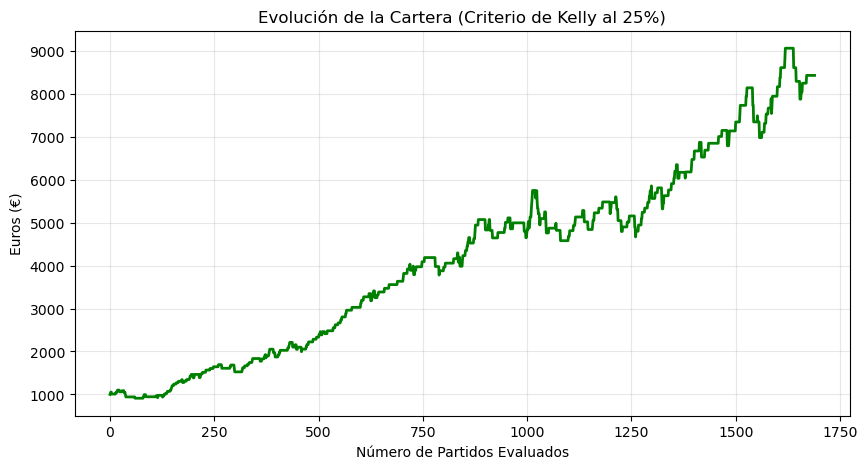

In [55]:
import matplotlib.pyplot as plt

print("🏦 INICIANDO SIMULACIÓN DE CAPITAL (CRITERIO DE KELLY)...")

bankroll_inicial = 1000.0
bankroll = bankroll_inicial
historial_bankroll = [bankroll]

apostado_total = 0
apuestas_realizadas = 0
aciertos_kelly = 0

# Usaremos las predicciones que ya calculamos en el paso anterior (probs_test_ensemble)
# y el DataFrame de prueba real (df_test_real)
df_sim_kelly = df_test_real.reset_index(drop=True)

for i in range(len(df_sim_kelly)):
    row = df_sim_kelly.iloc[i]
    odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
    p_L, p_E, p_V = probs_test_ensemble[i]
    
    odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
    odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
    
    ev_L = (p_L * odd_L) - 1
    ev_V = (p_V * odd_V) - 1
    ev_1X = ((p_L + p_E) * odd_1X) - 1
    ev_X2 = ((p_E + p_V) * odd_X2) - 1
    
    bet = None
    p_bet = 0
    odd_bet = 0
    
    # Filtro de disparo (Usando Umbral Óptimo de Optuna)
    if ev_L > umbral_optimo:
        if p_L > 0.45: bet = {'res': 0}; p_bet = p_L; odd_bet = odd_L
        elif ev_1X > 0.02: bet = {'res': [0,1]}; p_bet = p_L + p_E; odd_bet = odd_1X
    elif ev_V > umbral_optimo:
        if p_V > 0.45: bet = {'res': 2}; p_bet = p_V; odd_bet = odd_V
        elif ev_X2 > 0.02: bet = {'res': [1,2]}; p_bet = p_E + p_V; odd_bet = odd_X2
            
    if bet:
        # FÓRMULA DE KELLY
        b = odd_bet - 1 # Ganancia neta
        q = 1 - p_bet   # Probabilidad de perder
        
        kelly_fraction = (b * p_bet - q) / b
        
        # Ajustes de Seguridad: Quarter Kelly y Cap del 5%
        kelly_ajustado = max(0, kelly_fraction * 0.25)
        porcentaje_a_apostar = min(kelly_ajustado, 0.05)
        
        stake = bankroll * porcentaje_a_apostar
        
        # Solo apostamos si el monto tiene sentido (> 1 euro)
        if stake > 1.0:
            apuestas_realizadas += 1
            apostado_total += stake
            real_target = row['target_winner']
            win = False
            
            if isinstance(bet['res'], list):
                if real_target in bet['res']: win = True
            else:
                if real_target == bet['res']: win = True
                
            if win:
                bankroll += (stake * b)
                aciertos_kelly += 1
            else:
                bankroll -= stake
                
    historial_bankroll.append(bankroll)

# REPORTE FINANCIERO
roi_kelly = ((bankroll - bankroll_inicial) / apostado_total * 100) if apostado_total > 0 else 0
crecimiento_cuenta = ((bankroll / bankroll_inicial) - 1) * 100

print("-" * 50)
print(f"💶 Capital Inicial: {bankroll_inicial:.2f}€")
print(f"💰 Capital Final:   {bankroll:.2f}€")
print(f"🚀 Crecimiento de la Cuenta: {crecimiento_cuenta:.2f}%")
print("-" * 50)
print(f"💵 Total Dinero Movido: {apostado_total:.2f}€")
print(f"📈 ROI Promedio (Kelly): {roi_kelly:.2f}%")
print(f"🎯 Hit Rate: {aciertos_kelly}/{apuestas_realizadas} ({(aciertos_kelly/max(apuestas_realizadas, 1))*100:.2f}%)")
print("-" * 50)

# Gráfica del Bankroll
plt.figure(figsize=(10, 5))
plt.plot(historial_bankroll, color='green', linewidth=2)
plt.title('Evolución de la Cartera (Criterio de Kelly al 25%)')
plt.xlabel('Número de Partidos Evaluados')
plt.ylabel('Euros (€)')
plt.grid(True, alpha=0.3)
plt.show()

El resultado obtenido es aún mejor, los aciertos se mantienen ya que la red no cambia de decisión, sin embargo, la ganancia se maximiza tomando en cuenta el criterio de Kelly ya que invierte más en algunas apuestas cuyo valor ofrecido es coonsiderable, se ha llegado a un crecimiento del $842$ % de la inversión inicial, algo impresionante.

El siguiete código simplemente toma los modelos y hace una predicción del partido según las cuotas en la casa de apuestas y el partido que se va a jugar, es el paso para predecir partidos que aún no se han jugado.

In [56]:
import pandas as pd
import numpy as np

print("🔮 INICIALIZANDO ORÁCULO DE PRODUCCIÓN (SUPER EQUIPO)...")

def oraculo_produccion(equipo_local, equipo_visita, odd_L, odd_E, odd_V, bankroll=1000.0):
    print(f"\n==================================================")
    print(f"🏟️ PARTIDO: {equipo_local} vs {equipo_visita}")
    print(f"💰 BANKROLL DISPONIBLE: {bankroll:.2f}€")
    print(f"==================================================")
    
    try:
        # 1. Buscar los últimos datos conocidos de ambos equipos en tu base histórica
        row_h = df_final_elo[df_final_elo['HomeTeam'] == equipo_local].sort_values('Date').iloc[-1]
        row_a = df_final_elo[df_final_elo['AwayTeam'] == equipo_visita].sort_values('Date').iloc[-1]
        
        # 2. Calcular la diferencia de ELO actual (Sumamos 50 al local por la ventaja de casa)
        elo_diff = (row_h['Elo_Home'] + 50) - row_a['Elo_Away']
        
        # 3. Construir el Input exacto que requiere el modelo
        input_w = pd.DataFrame({
            'Elo_Diff': [elo_diff], 'Elo_Home': [row_h['Elo_Home']], 'Elo_Away': [row_a['Elo_Away']],
            'Odds_Home': [odd_L], 'Odds_Draw': [odd_E], 'Odds_Away': [odd_V],
            'Home_Shots_Total_For_Form': [row_h['Home_Shots_Total_For_Form']],
            'Home_Shots_Target_For_Form': [row_h['Home_Shots_Target_For_Form']],
            'Home_Goals_For_Form': [row_h['Home_Goals_For_Form']],
            'Home_Goals_Ag_Form': [row_h['Home_Goals_Ag_Form']],
            'Home_Pts_Form': [row_h['Home_Pts_Form']],
            'Away_Shots_Total_For_Form': [row_a['Away_Shots_Total_For_Form']],
            'Away_Shots_Target_For_Form': [row_a['Away_Shots_Target_For_Form']],
            'Away_Goals_For_Form': [row_a['Away_Goals_For_Form']],
            'Away_Goals_Ag_Form': [row_a['Away_Goals_Ag_Form']],
            'Away_Pts_Form': [row_a['Away_Pts_Form']]
        })
        
        # 4. Escalar los datos solo para la Red Neuronal (Usamos el scaler que ya tenías)
        input_w_scaled = scaler_w.transform(input_w)
        
        # 5. CONSULTA AL SUPER EQUIPO (Fusión)
        prob_xgb = modelo_final_xgb.predict_proba(input_w)[0]
        prob_nn = modelo_final_nn.predict(input_w_scaled, verbose=0)[0]
        p_w = (prob_xgb + prob_nn) / 2.0
        
        # 6. MATEMÁTICAS DE APUESTAS (EV y Cuotas Dobles)
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        ev_L = (p_w[0] * odd_L) - 1
        ev_V = (p_w[2] * odd_V) - 1
        ev_1X = ((p_w[0] + p_w[1]) * odd_1X) - 1
        ev_X2 = ((p_w[1] + p_w[2]) * odd_X2) - 1
        
        print(f"📊 PREDICCIÓN IA: Local {p_w[0]:.1%} | Empate {p_w[1]:.1%} | Visita {p_w[2]:.1%}")
        
        # 7. GESTIÓN DE CAPITAL (Quarter Kelly con tope del 5%)
        def calcular_inversion(probabilidad, cuota):
            b = cuota - 1
            q = 1 - probabilidad
            kelly_puro = (b * probabilidad - q) / b
            kelly_ajustado = max(0, kelly_puro * 0.25)
            inversion_final = min(kelly_ajustado, 0.05) # Cap del 5%
            return inversion_final
        
        # 8. EMITIR RECOMENDACIONES
        hay_apuesta = False
        
        # Usamos tu umbral de oro extraído de Optuna (umbral_optimo)
        print("-" * 50)
        
        if ev_L > umbral_optimo and p_w[0] > 0.45:
            inv = calcular_inversion(p_w[0], odd_L)
            if inv > 0:
                print(f"🟢 ALERTA DE VALOR: Apostar a GANA LOCAL")
                print(f"   Cuota: {odd_L} | Ventaja Matemática (EV): +{ev_L:.2%}")
                print(f"   👉 INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}% de tu bankroll)")
                hay_apuesta = True
                
        elif ev_1X > umbral_optimo:
            inv = calcular_inversion(p_w[0] + p_w[1], odd_1X)
            if inv > 0:
                print(f"🟡 ALERTA DE VALOR SEGURA: Apostar a DOBLE 1X (Local o Empate)")
                print(f"   Cuota: {odd_1X:.2f} | Ventaja Matemática (EV): +{ev_1X:.2%}")
                print(f"   👉 INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}% de tu bankroll)")
                hay_apuesta = True

        if ev_V > umbral_optimo and p_w[2] > 0.45:
            inv = calcular_inversion(p_w[2], odd_V)
            if inv > 0:
                print(f"🟢 ALERTA DE VALOR: Apostar a GANA VISITA")
                print(f"   Cuota: {odd_V} | Ventaja Matemática (EV): +{ev_V:.2%}")
                print(f"   👉 INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}% de tu bankroll)")
                hay_apuesta = True
                
        elif ev_X2 > umbral_optimo:
            inv = calcular_inversion(p_w[1] + p_w[2], odd_X2)
            if inv > 0:
                print(f"🟡 ALERTA DE VALOR SEGURA: Apostar a DOBLE X2 (Visita o Empate)")
                print(f"   Cuota: {odd_X2:.2f} | Ventaja Matemática (EV): +{ev_X2:.2%}")
                print(f"   👉 INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}% de tu bankroll)")
                hay_apuesta = True

        if not hay_apuesta:
            print("💤 SIN VALOR SUFICIENTE. La IA recomienda NO apostar en este partido.")
            print(f"   (Ninguna opción supera tu umbral exigente del {umbral_optimo:.2%})")
            
        print("==================================================\n")

    except Exception as e:
        print(f"❌ Error buscando a los equipos: {e}")
        print("   Asegúrate de escribir los nombres exactamente como aparecen en el Excel (Ej: 'Real Madrid', no 'R. Madrid').")

print("✅ Oráculo listo para usar.")

🔮 INICIALIZANDO ORÁCULO DE PRODUCCIÓN (SUPER EQUIPO)...
✅ Oráculo listo para usar.


In [59]:
oraculo_produccion('Ath Madrid','Tottenham',1.54,4.35,5.53,100)


🏟️ PARTIDO: Ath Madrid vs Tottenham
💰 BANKROLL DISPONIBLE: 100.00€
📊 PREDICCIÓN IA: Local 71.6% | Empate 18.0% | Visita 10.4%
--------------------------------------------------
🟢 ALERTA DE VALOR: Apostar a GANA LOCAL
   Cuota: 1.54 | Ventaja Matemática (EV): +10.32%
   👉 INVERTIR: 4.78€ (4.78% de tu bankroll)



In [57]:
import joblib

print("💾 INICIANDO PROTOCOLO DE EXPORTACIÓN...")

# 1. Guardar el modelo XGBoost y el Escalador (Usamos joblib que es genial para Scikit-Learn/XGB)
joblib.dump(modelo_final_xgb, 'oraculo_xgboost.pkl')
joblib.dump(scaler_w, 'oraculo_scaler.pkl')
print("   ✅ XGBoost y Escalador guardados (.pkl)")

# 2. Guardar la Red Neuronal (Keras tiene su propio formato optimizado)
modelo_final_nn.save('oraculo_red_neuronal.keras')
print("   ✅ Red Neuronal guardada (.keras)")

# 3. Guardar tu Umbral Óptimo de Optuna (Para que el oráculo sepa cuándo disparar)
joblib.dump(umbral_optimo, 'oraculo_umbral.pkl')
print("   ✅ Umbral de disparo guardado (.pkl)")

print("\n🎉 ¡SUPER EQUIPO CONGELADO CON ÉXITO!")
print("Ahora puedes apagar la computadora. Tus modelos están a salvo en tu carpeta.")

💾 INICIANDO PROTOCOLO DE EXPORTACIÓN...
   ✅ XGBoost y Escalador guardados (.pkl)
   ✅ Red Neuronal guardada (.keras)
   ✅ Umbral de disparo guardado (.pkl)

🎉 ¡SUPER EQUIPO CONGELADO CON ÉXITO!
Ahora puedes apagar la computadora. Tus modelos están a salvo en tu carpeta.
